In [1]:
#############################################
# 1. Import Libraries & Mount Drive
#############################################
import os
import time
import zipfile
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from google.colab import drive

In [2]:
#############################################
# 2. Data Loading Function
#############################################
def get_data_loaders(data_dir, batch_size=32, img_size=(256, 256)):
    transform = transforms.Compose([
        transforms.Resize(img_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])
    train_dataset = datasets.ImageFolder(os.path.join(data_dir, 'train'), transform)
    val_dataset = datasets.ImageFolder(os.path.join(data_dir, 'valid'), transform)
    test_dataset = datasets.ImageFolder(os.path.join(data_dir, 'test'), transform)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
    return train_loader, val_loader, test_loader

In [3]:
#############################################
# 3. Define Training and Evaluation Functions
#############################################
def train_model(model, train_loader, val_loader, num_epochs, optimizer, criterion, device, scheduler=None):
    model.to(device)
    best_val_acc = 0.0
    best_model_path = 'best_model.pth'

    train_losses, train_accs = [], []
    val_losses, val_accs = [], []

    for epoch in range(1, num_epochs + 1):
        start_time = time.time()
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

        epoch_loss = running_loss / total
        epoch_acc = 100 * correct / total
        train_losses.append(epoch_loss)
        train_accs.append(epoch_acc)

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (preds == labels).sum().item()
        val_loss /= val_total
        val_acc = 100 * val_correct / val_total
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        epoch_time = time.time() - start_time
        samples_per_sec = total / epoch_time

        print(f"Epoch {epoch}/{num_epochs} | "
              f"Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}% | "
              f"Time: {epoch_time:.2f}s | {samples_per_sec:.2f} samples/s")

        if scheduler:
            scheduler.step(epoch)
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), best_model_path)
            print(f"Best model saved to {best_model_path}")

    # Plot training and validation loss curves
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.title('Loss Curves')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Plot training and validation accuracy curves
    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label='Train Accuracy')
    plt.plot(val_accs, label='Val Accuracy')
    plt.title('Accuracy Curves')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()

    plt.tight_layout()
    plt.show()

In [4]:
def evaluate_model(model, test_loader, device, class_names, model_path='best_model.pth'):
    """
    Evaluates the model on the test dataset.

    Args:
        model: The model to evaluate.
        test_loader: DataLoader for the test dataset.
        device: The device to use for computation (e.g., 'cuda' or 'cpu').
        class_names: A list of class names.
        model_path: Path to the model file to load. Defaults to 'best_model.pth'.
    """
    model.load_state_dict(torch.load(model_path))  # Load from the specified path
    model.to(device)
    model.eval()

    y_true, y_pred = [], []
    total, correct = 0, 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    test_acc = 100 * correct / total
    print(f"\nTest Accuracy: {test_acc:.2f}%")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

In [5]:
def plot_true_vs_predicted(model, test_loader, device, class_names, num_examples=16):
    model.load_state_dict(torch.load('best_model.pth'))
    model.to(device).eval()

    # Get a batch of test data
    inputs, labels = next(iter(test_loader))
    inputs = inputs.to(device)

    # Get predictions
    with torch.no_grad():
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

    # Denormalize images for visualization
    def denormalize(image):
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1).to(device)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1).to(device)
        return image * std + mean

    # Plot true vs predicted images in a 4x4 grid
    plt.figure(figsize=(12, 12))  # Adjust figure size for 16 images
    for idx in range(num_examples):
        img = denormalize(inputs[idx]).cpu().permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)  # Clip to valid image range

        plt.subplot(4, 4, idx + 1)  # 4 rows, 4 columns
        plt.imshow(img)
        plt.title(f"True: {class_names[labels[idx]]}\nPred: {class_names[predicted[idx]]}", fontsize=8)  # Smaller font size
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [6]:
# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
#############################################
# 4. Set Paths, Extract Dataset & Create Data Loaders
#############################################
dataset_path = '/content/drive/MyDrive/My Datasets/Tea_Betel_Leaf_Final_Dataset(1).zip'
extract_path = '/content/data'
batch_size = 16
img_size = (256, 256)
num_classes = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with zipfile.ZipFile(dataset_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
data_dir = os.path.join(extract_path, 'Tea_Betel_Leaf_Final_Dataset')
train_loader, val_loader, test_loader = get_data_loaders(data_dir, batch_size, img_size)
class_names = train_loader.dataset.classes
print("Classes:", class_names)

Classes: ['betel_Bacterial Leaf Disease', 'betel_Dried Leaf', 'betel_Fungal Brown Spot Disease', 'betel_Healthy Leaf', 'tea_algal_spot', 'tea_brown_blight', 'tea_gray_blight', 'tea_healthy', 'tea_helopeltis', 'tea_red_spot']


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [8]:
#############################################
# 5. Define Simple CNN & Instantiate Model
#############################################
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            # Conv Layer 1 -> Pool 1
            nn.Conv2d(3, 24, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv Layer 2 -> Pool 2
            nn.Conv2d(24, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv Layer 3 -> Pool 3
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv Layer 4 -> Pool 4
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv Layer 5 -> Pool 5
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv Layer 6 -> Pool 6
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        # After 6 pools on 256×256 input we get feature-maps of size 4×4:
        #   256 →128→64→32→16→8→4
        flat_dim = 64 * 4 * 4

        self.classifier = nn.Sequential(
            nn.Flatten(),
            # Full Conn. Layer 7
            nn.Linear(flat_dim, 64),
            nn.ReLU(inplace=True),
            # Full Conn. Layer 8
            nn.Linear(64, 10),
            nn.ReLU(inplace=True),
            # Final classification layer
            nn.Linear(10, num_classes),
            nn.Softmax(dim=1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [9]:
# instantiate
model = SimpleCNN(num_classes)

In [10]:
!pip install torchinfo

In [11]:
from torchinfo import summary

In [12]:
# Analyze the model after Stage 1 training
print("\nModel Analysis:")
summary(model, input_size=(1, 3, img_size[0], img_size[1]))


Model Analysis:


Layer (type:depth-idx)                   Output Shape              Param #
SimpleCNN                                [1, 10]                   --
├─Sequential: 1-1                        [1, 64, 4, 4]             --
│    └─Conv2d: 2-1                       [1, 24, 256, 256]         672
│    └─ReLU: 2-2                         [1, 24, 256, 256]         --
│    └─MaxPool2d: 2-3                    [1, 24, 128, 128]         --
│    └─Conv2d: 2-4                       [1, 64, 128, 128]         13,888
│    └─ReLU: 2-5                         [1, 64, 128, 128]         --
│    └─MaxPool2d: 2-6                    [1, 64, 64, 64]           --
│    └─Conv2d: 2-7                       [1, 64, 64, 64]           36,928
│    └─ReLU: 2-8                         [1, 64, 64, 64]           --
│    └─MaxPool2d: 2-9                    [1, 64, 32, 32]           --
│    └─Conv2d: 2-10                      [1, 64, 32, 32]           36,928
│    └─ReLU: 2-11                        [1, 64, 32, 32]           --
│ 

Epoch 1/40 | Train Loss: 2.1128 Acc: 33.72% | Val Loss: 2.0319 Acc: 41.84% | Time: 21.32s | 323.85 samples/s
Best model saved to best_model.pth
Epoch 2/40 | Train Loss: 2.0185 Acc: 43.82% | Val Loss: 2.0048 Acc: 44.86% | Time: 22.00s | 313.86 samples/s
Best model saved to best_model.pth
Epoch 3/40 | Train Loss: 2.0032 Acc: 45.41% | Val Loss: 1.9867 Acc: 46.74% | Time: 20.82s | 331.78 samples/s
Best model saved to best_model.pth
Epoch 4/40 | Train Loss: 1.9567 Acc: 49.97% | Val Loss: 2.0021 Acc: 45.47% | Time: 23.21s | 297.57 samples/s
Epoch 5/40 | Train Loss: 1.9381 Acc: 51.97% | Val Loss: 1.9185 Acc: 53.79% | Time: 20.72s | 333.36 samples/s
Best model saved to best_model.pth
Epoch 6/40 | Train Loss: 1.9143 Acc: 54.56% | Val Loss: 1.9198 Acc: 53.79% | Time: 21.94s | 314.76 samples/s
Epoch 7/40 | Train Loss: 1.9082 Acc: 55.11% | Val Loss: 1.9131 Acc: 54.40% | Time: 21.40s | 322.77 samples/s
Best model saved to best_model.pth
Epoch 8/40 | Train Loss: 1.8881 Acc: 57.17% | Val Loss: 1.9336

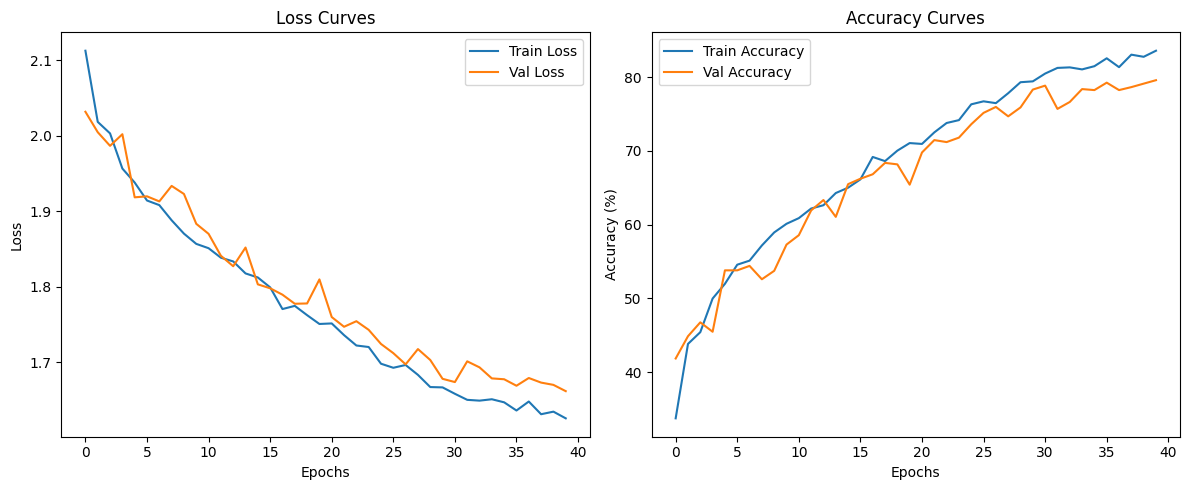

In [13]:
criterion = nn.CrossEntropyLoss()
optimizer_stage1 = optim.Adam(model.parameters(), lr=3e-4)

train_model(model, train_loader, val_loader, num_epochs=40, optimizer=optimizer_stage1,
            criterion=criterion, device=device)


Test Accuracy: 79.62%

Classification Report:
                                 precision    recall  f1-score   support

   betel_Bacterial Leaf Disease       0.49      1.00      0.65       148
               betel_Dried Leaf       0.97      0.98      0.98       148
betel_Fungal Brown Spot Disease       0.97      0.95      0.96       148
             betel_Healthy Leaf       0.00      0.00      0.00       148
                 tea_algal_spot       0.94      0.87      0.90       150
               tea_brown_blight       0.79      0.72      0.75       130
                tea_gray_blight       0.78      0.88      0.82       150
                    tea_healthy       0.82      0.91      0.86       150
                 tea_helopeltis       0.92      0.81      0.86       150
                   tea_red_spot       0.85      0.83      0.84       150

                       accuracy                           0.80      1472
                      macro avg       0.75      0.79      0.76      1472
  

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


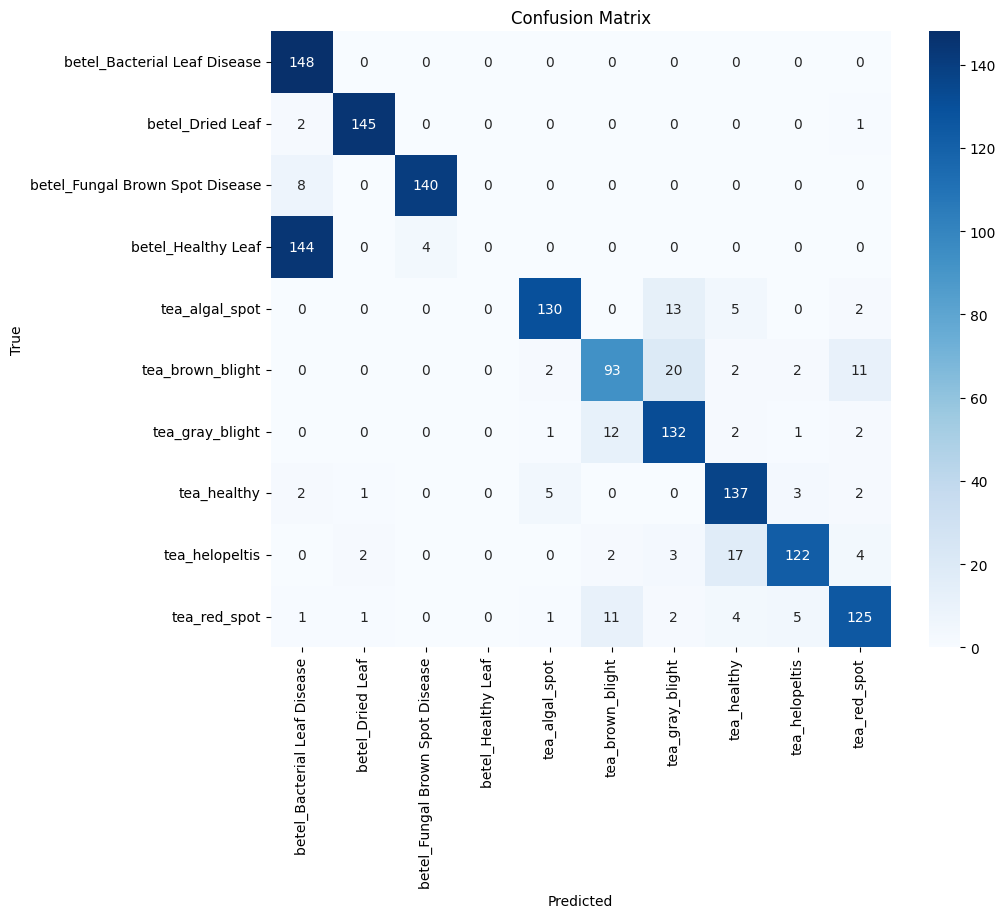

In [14]:
evaluate_model(model, test_loader, device, class_names)

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


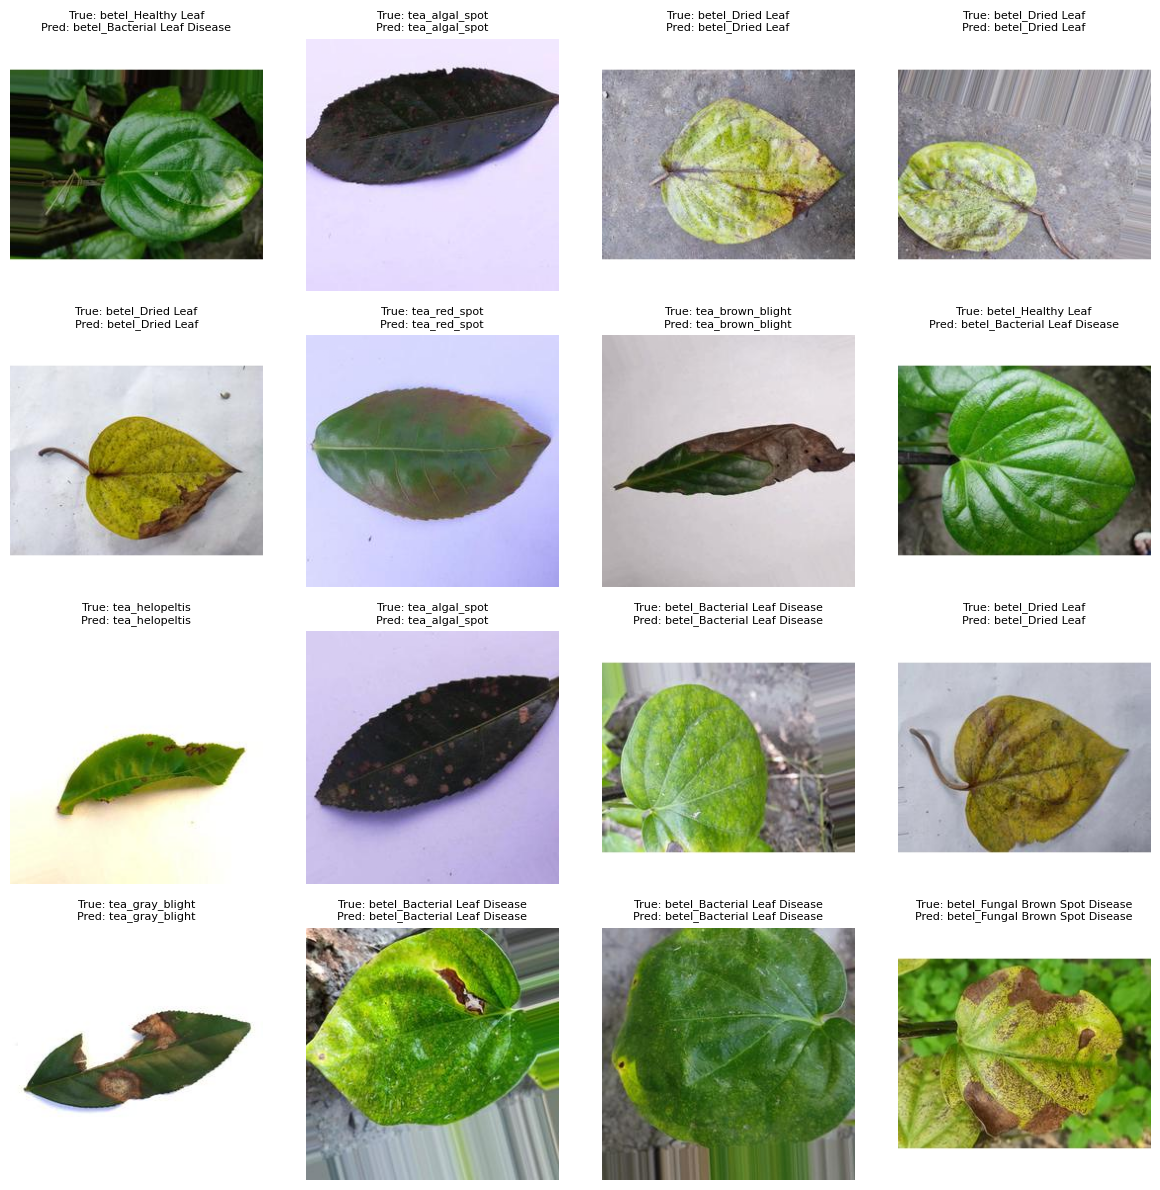

In [15]:
plot_true_vs_predicted(model, test_loader, device, class_names)